Accuracy on linear blobs: 100.00%


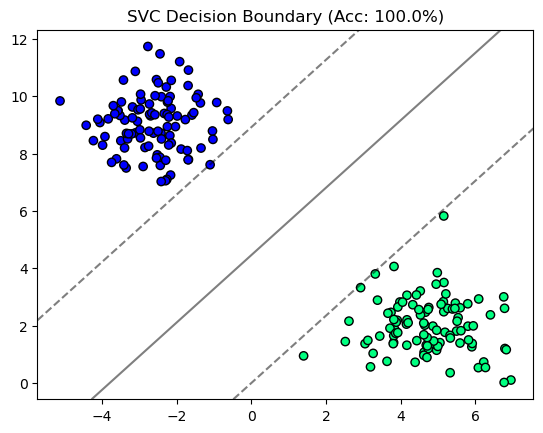

In [2]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from svm import SVC

# Здесь предполагается, что твой класс называется MySVC
# from your_library import MySVC 

def test_svm():
    # 1. Генерация линейно разделимых данных
    X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.0)
    
    # SVC ожидает метки {-1, 1}
    y = np.where(y <= 0, -1, 1)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Инициализация и обучение твоей модели
    # Настраиваем параметры под конкретную задачу
    model = SVC(lr=0.001, C=1.0, max_iter=1000, batch_size=32)
    model.fit(X_train, y_train)

    # 3. Предсказание
    y_pred = model.predict(X_test)
    
    # 4. Проверка точности
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy on linear blobs: {acc * 100:.2f}%")

    # Визуализация разделяющей прямой
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Считаем решающую функцию: Z = Xw + b
    Z = (xy @ model.coef_ + model.intercept_).reshape(XX.shape)

    # Рисуем разделяющую плоскость и зазоры
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    plt.title(f"SVC Decision Boundary (Acc: {acc*100:.1f}%)")
    plt.show()

if __name__ == "__main__":
    test_svm()